# Image Classification with CNN from Scratch

## 1. Preparation

### 1.1 Env

In [1]:


# # %cd /kaggle/working
# !rm -rf cnn_rnn_lstm
# !git clone -b feat/cnn-notebook https://github.com/grwna/cnn_rnn_lstm.git

In [2]:
import os
import sys

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, "../../"))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.cnn.model import CNNScratch
print("Import successful")

Import successful


### 1.2 Importing Libraries

In [30]:
import os
import sys
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

### 1.3 Data Loading

In [4]:
BASE_DIR = '../..//data/images-intel/'
TRAIN_DIR = os.path.join(BASE_DIR, 'intel_train')
TEST_DIR = os.path.join(BASE_DIR, 'intel_test')

In [5]:
import random

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
SEED = 42

def enforce_reproducibility(seed: int):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    tf.keras.utils.set_random_seed(seed)
    print("Reproducibility is set succesfully")
enforce_reproducibility(SEED)

train_generator = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int' # Equivalent to class_mode='sparse'
)

val_generator = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_generator = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = train_generator.class_names
print(f"Categories: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_generator = train_generator.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_generator = val_generator.cache().prefetch(buffer_size=AUTOTUNE)
test_generator = test_generator.prefetch(buffer_size=AUTOTUNE)

Reproducibility is set succesfully
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


W0000 00:00:1778923790.997856   62626 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Categories: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2. EDA

### 2.1 Distribusi Kelas

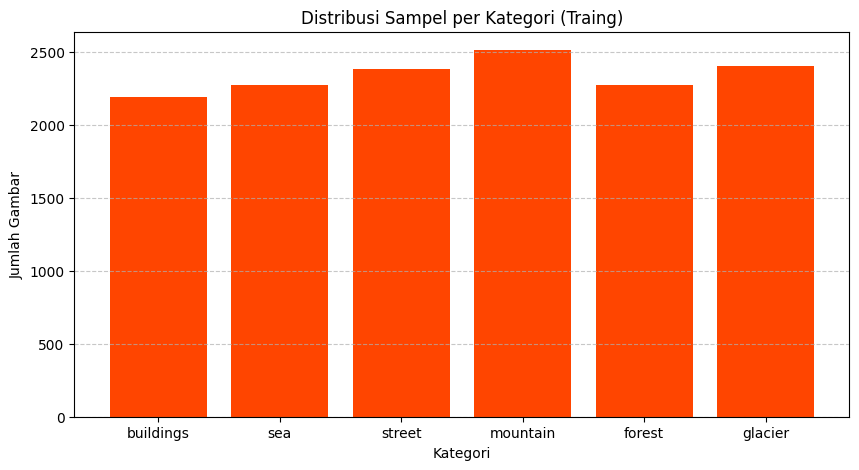

Kategori buildings : 2191 gambar
Kategori sea       : 2274 gambar
Kategori street    : 2382 gambar
Kategori mountain  : 2512 gambar
Kategori forest    : 2271 gambar
Kategori glacier   : 2404 gambar


In [6]:
train_counts = {}
for category in os.listdir(TRAIN_DIR):
    category_path = os.path.join(TRAIN_DIR, category)
    if os.path.isdir(category_path):
        train_counts[category] = len(os.listdir(category_path))

plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values(), color='orangered')
plt.title('Distribusi Sampel per Kategori (Traing)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for cat, count in train_counts.items():
    print(f"Kategori {cat:10}: {count} gambar")

### 2.2 Visualisasi Sampel Gambar

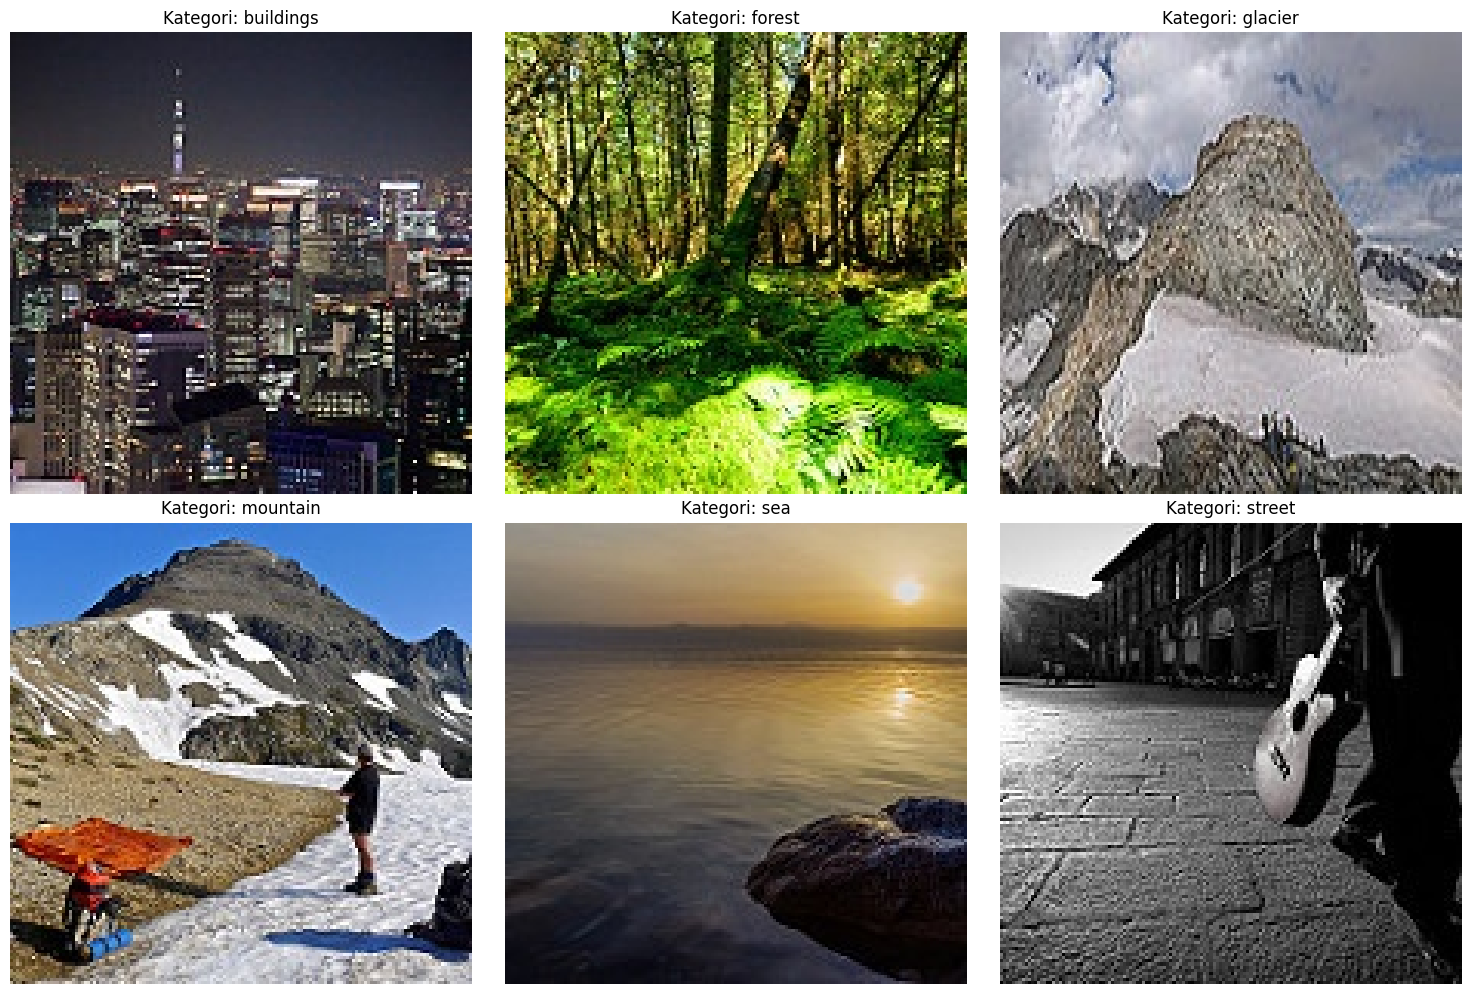

In [7]:
from src.utils.image_utils import load_image

# 1 sample per kategori
plt.figure(figsize=(15, 10))
categories = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])

for i, category in enumerate(categories):
    path = os.path.join(TRAIN_DIR, category)
    sample_img_name = os.listdir(path)[0]
    sample_img_path = os.path.join(path, sample_img_name)
    
    img_array = load_image(sample_img_path, target_size=(150, 150))
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_array)
    plt.title(f"Kategori: {category}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2.3 Analisis Resolusi dan Karakteristik Gambar

In [8]:

resolutions = []
sample_size = 100 

for category in categories:
    folder_path = os.path.join(TRAIN_DIR, category)
    files = os.listdir(folder_path)[:sample_size]
    for f in files:
        with Image.open(os.path.join(folder_path, f)) as img:
            resolutions.append(img.size)

resolutions = np.array(resolutions)
unique_res, counts = np.unique(resolutions, axis=0, return_counts=True)

print("Resolution Analysis:")
for res, count in zip(unique_res, counts):
    print(f"{res[0]}x{res[1]}: {count} images")

print(f"Average Resolution: {np.mean(resolutions, axis=0)}")

Resolution Analysis:
150x105: 1 images
150x150: 599 images
Average Resolution: [150.    149.925]


### 2.4 Analisis Konsistensi Channel

In [9]:
def check_channels(directory):
    non_rgb_files = []
    for category in categories:
        folder_path = os.path.join(directory, category)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                with Image.open(fpath) as img:
                    if img.mode != 'RGB':
                        non_rgb_files.append((fpath, img.mode))
            except Exception:
                continue
    return non_rgb_files

train_issues = check_channels(TRAIN_DIR)
test_issues = check_channels(TEST_DIR)

if not train_issues and not test_issues:
    print("All images are consistent with RGB")
else:
    print(f"[ERROR] Found {len(train_issues)} non-RGB.")
    print(f"[ERROR] Found {len(test_issues)} non-RGB.")
    for path, mode in (train_issues + test_issues)[:5]: # examples
        print(f"  - {path}: Mode {mode}")


All images are consistent with RGB


## 3. Data Preprocessing

Preprocessing yang dilakukan terdiri dari Rescaling, Resizing, dan Augmentasi, yang akan dilakukan di dalam kode factory di bawah.

## 4. Training 

### 4.1 Model Factory

In [10]:
def cnn_model_factory(n_conv_layers, n_filters, kernel_size, pooling_type):
    # Factory for variaton testing
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(150, 150, 3)))
    model.add(tf.keras.layers.Rescaling(1./255))
    
    model.add(tf.keras.layers.RandomRotation(0.055))
    model.add(tf.keras.layers.RandomFlip("horizontal"))
    
    # Convolution Layers
    for i in range(n_conv_layers):
        # first layer uses input shape
        if i == 0:
            model.add(tf.keras.layers.Conv2D(
                filters=n_filters, 
                kernel_size=kernel_size, 
                activation='relu', 
                padding='same', 
                input_shape=(150, 150, 3),
                name=f"conv2d_layer_{i}"
            ))
        else:
            model.add(tf.keras.layers.Conv2D(
                filters=n_filters, 
                kernel_size=kernel_size, 
                activation='relu', 
                padding='same',
                name=f"conv2d_layer_{i}"
            ))
        
        # Pooling Types
        if pooling_type.lower() == 'max':
            model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"max_pool_{i}"))
        elif pooling_type.lower() == 'average':
            model.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), name=f"avg_pool_{i}"))

    # Classifiers
    model.add(tf.keras.layers.Flatten(name="flatten_layer"))
    model.add(tf.keras.layers.Dense(128, activation='relu', name="dense_hidden"))
    # Output layer has 6 categories
    model.add(tf.keras.layers.Dense(6, activation='softmax', name="dense_output"))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Verification
temp_model = cnn_model_factory(n_conv_layers=2, n_filters=32, kernel_size=(3,3), pooling_type='max')
temp_model.summary()

/home/grwna/Github/CNN_RNN_LSTM/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_layer_0 (Conv2D)         │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_0 (MaxPooling2D)       │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_layer_1 (Conv2D)         │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 43808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     5,607,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,618,470 (21.43 MB)

 Trainable params: 5,618,470 (21.43 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Training 16 Variations

In [11]:
# Helpers
import time
from datetime import datetime
import pickle

def print_execute_time(start_time, end_time):
    duration = end_time - start_time
    
    hours, remainder = divmod(duration, 3600)
    minutes, seconds = divmod(remainder, 60)
    
    result = f"({int(hours)} hours, {int(minutes)} minutes, {seconds:.2f} seconds)"
    print(result)

def load_experiment_results(pkl_path):
    with open(pkl_path, 'rb') as f:
        loaded_results = pickle.load(f)
    return loaded_results


In [12]:
import pandas as pd


y_true = np.concatenate([y for x, y in test_generator], axis=0)

# Variations
n_conv_vars = [2, 3]
n_filt_vars = [32, 64]
k_size_vars = [(3, 3), (5, 5)]
pool_vars = ['max', 'average']

# Folder output
model_out_dir = '../../models/cnn_keras'
output_dir = '../../outputs'
os.makedirs(model_out_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
results_pkl_path = os.path.join(output_dir, 'cnn_training_results.pkl')

all_results = []

# Variations Loop
counter_train = 0
total_models = len(n_conv_vars) * len(n_filt_vars) * len(k_size_vars) * len(pool_vars)

start = time.time()
if os.path.exists(results_pkl_path):
    all_results = load_experiment_results(results_pkl_path)
    print("Results loaded, skipping training+")
else:
    for n_conv in n_conv_vars:
        for n_filt in n_filt_vars:
            for k_size in k_size_vars:
                for pool in pool_vars:
                    counter_train += 1
                    model_name = f"CNN_L{n_conv}_F{n_filt}_K{k_size[0]}_P{pool}"
                    print(f"\n>>> Training model ({counter_train}/{total_models}): {model_name}")
                    
                    # build model
                    model = cnn_model_factory(n_conv, n_filt, k_size, pool)
                    
                    # Training
                    history = model.fit(
                        train_generator,
                        validation_data=val_generator,
                        epochs=5, 
                        verbose=1
                    )
                    
                    # Test set prediction
                    y_pred_probs = model.predict(test_generator)
                    y_pred = np.argmax(y_pred_probs, axis=1)
                    
                    # evaluate
                    f1 = f1_score(y_true, y_pred, average='macro')
                    print(f"Hasil Macro F1-score: {f1:.4f}")
                    
                    # store weights
                    weight_path = os.path.join(model_out_dir, f"{model_name}.weights.h5")
                    model.save_weights(weight_path)
                    
                    all_results.append({
                        'model_name': model_name,
                        'n_layers': n_conv,
                        'n_filters': n_filt,
                        'kernel_size': k_size[0],
                        'pooling': pool,
                        'f1_score': f1,
                        'weight_path': weight_path,
                        'history': history.history,
                        'y_pred': y_pred
                    })




with open(results_pkl_path, 'wb') as f:
    pickle.dump(all_results, f)

summary_results = [{k: v for k, v in res.items() if k != 'history'} for res in all_results]
df_results = pd.DataFrame(summary_results)

df_results_sorted = df_results.sort_values(by='f1_score', ascending=False)

print("\n>>> Ringkasan Hasil Eksperimen:")
display(df_results_sorted) 


print_execute_time(start, time.time())

Results loaded, skipping training+

>>> Ringkasan Hasil Eksperimen:


,model_name,n_layers,n_filters,kernel_size,pooling,f1_score,weight_path,y_pred
8,CNN_L3_F32_K3_Pmax,3,32,3,max,0.821937,./models/cnn_keras/CNN_L3_F32_K3_Pmax.weights.h5,"[0, 0, 0, 0, 4, 3, 0, 5, 0, 0, 0, 0, 0, 0, 0, ..."
12,CNN_L3_F64_K3_Pmax,3,64,3,max,0.817966,./models/cnn_keras/CNN_L3_F64_K3_Pmax.weights.h5,"[0, 5, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CNN_L2_F64_K3_Pmax,2,64,3,max,0.812895,./models/cnn_keras/CNN_L2_F64_K3_Pmax.weights.h5,"[0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,CNN_L2_F32_K3_Pmax,2,32,3,max,0.811519,./models/cnn_keras/CNN_L2_F32_K3_Pmax.weights.h5,"[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 5, 0, ..."
14,CNN_L3_F64_K5_Pmax,3,64,5,max,0.794112,./models/cnn_keras/CNN_L3_F64_K5_Pmax.weights.h5,"[0, 0, 0, 4, 4, 3, 0, 5, 0, 0, 0, 0, 0, 0, 0, ..."
13,CNN_L3_F64_K3_Paverage,3,64,3,average,0.793477,./models/cnn_keras/CNN_L3_F64_K3_Paverage.weig...,"[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,CNN_L3_F32_K3_Paverage,3,32,3,average,0.792048,./models/cnn_keras/CNN_L3_F32_K3_Paverage.weig...,"[0, 5, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CNN_L2_F32_K3_Paverage,2,32,3,average,0.784952,./models/cnn_keras/CNN_L2_F32_K3_Paverage.weig...,"[0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
10,CNN_L3_F32_K5_Pmax,3,32,5,max,0.783238,./models/cnn_keras/CNN_L3_F32_K5_Pmax.weights.h5,"[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
11,CNN_L3_F32_K5_Paverage,3,32,5,average,0.777046,./models/cnn_keras/CNN_L3_F32_K5_Paverage.weig...,"[0, 5, 0, 0, 4, 3, 0, 5, 0, 0, 0, 0, 0, 0, 0, ..."


(0 hours, 0 minutes, 0.03 seconds)


In [13]:
# from IPython.display import FileLink
# !zip -r cnn_outputs.zip ./outputs
# !tar -czf cnn_weights.tar.gz ./models/cnn_keras
# FileLink(r'cnn_outputs.zip')

Catatan: training dilakukan di Kaggle untuk mendapat Bobot dengan menggunakan GPU nya. Sedangkan notebook ini di jalankan ulang di laptop. Sehingga training tidak dilakukan pada sesi notebook ini, dan hanya melakukan loading bobot yang sudah didapat.

### 4.3 Get Best Model (Hyperparameter)

In [14]:
top_models = df_results.sort_values(by='f1_score', ascending=False).head(5)
print("Top 5")
display(top_models[['model_name', 'f1_score']])

best_row = top_models.iloc[0]
best_model = best_row['model_name']
print(f"\nArsitektur terbaik yang terpilih: {best_model}")

Top 5


,model_name,f1_score
8,CNN_L3_F32_K3_Pmax,0.821937
12,CNN_L3_F64_K3_Pmax,0.817966
4,CNN_L2_F64_K3_Pmax,0.812895
0,CNN_L2_F32_K3_Pmax,0.811519
14,CNN_L3_F64_K5_Pmax,0.794112



Arsitektur terbaik yang terpilih: CNN_L3_F32_K3_Pmax


## 5. Experiment and Evaluation

### 5.1 Load Weights

In [15]:
# Rebuild so weights is nparray
k_val = int(best_row['kernel_size'])
best_keras_model = cnn_model_factory(
    n_conv_layers=int(best_row['n_layers']),
    n_filters=int(best_row['n_filters']),
    kernel_size=(k_val, k_val),
    pooling_type=best_row['pooling']
)
if not best_row['weight_path'].startswith('../../'):
    best_row['weight_path'] = '../../' + best_row['weight_path']
best_keras_model.load_weights(best_row['weight_path'])

pool_type = best_row['pooling'].lower()

model_spec = []
for i in range(int(best_row['n_layers'])):
    model_spec.append({
        "name": f"conv2d_layer_{i}",
        "type": "Conv2D",
        "metadata": {
            "strides": (1, 1),
            "padding": "same"
        }
    })
    
    model_spec.append({
        "name": f"max_pool_{i}" if pool_type == 'max' else f"avg_pool_{i}",
        "type": "MaxPooling2D" if pool_type == 'max' else "AveragePooling2D",
        "metadata": {
            "pool_size": (2, 2),
            "strides": (2, 2),
            "padding": "valid"
        }
    })

model_spec.append({
    "name": "flatten_layer",
    "type": "Flatten",
    "metadata": {}
})

model_spec.append({
    "name": "dense_hidden",
    "type": "Dense",
    "metadata": {"activation": "relu"}
})

model_spec.append({
    "name": "dense_output",
    "type": "Dense",
    "metadata": {"activation": "softmax"}
})

print("\nmodel_spec successfully created!:")
for s in model_spec:
    print(f"- Layer: {s['name']} | Tipe: {s['type']}")


model_spec successfully created!:
- Layer: conv2d_layer_0 | Tipe: Conv2D
- Layer: max_pool_0 | Tipe: MaxPooling2D
- Layer: conv2d_layer_1 | Tipe: Conv2D
- Layer: max_pool_1 | Tipe: MaxPooling2D
- Layer: conv2d_layer_2 | Tipe: Conv2D
- Layer: max_pool_2 | Tipe: MaxPooling2D
- Layer: flatten_layer | Tipe: Flatten
- Layer: dense_hidden | Tipe: Dense
- Layer: dense_output | Tipe: Dense


/home/grwna/Github/CNN_RNN_LSTM/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_62626/3069237350.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_row['weight_path'] = '../../' + best_row['weight_path']
/home/grwna/Github/CNN_RNN_LSTM/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_pat

### 5.2 Konstruksi Arsitektur CNNScratch

In [50]:
import src.cnn.model as cnnscratch
import src.utils.weight_loaders as weight_loaders
CNNScratch = cnnscratch.CNNScratch

# shared
cnn_shared = CNNScratch(keras_model=best_keras_model, spec=model_spec)
print("Conv2D berhasil diinisialisasi.")


extracted_weights = weight_loaders.load_weights(best_keras_model, model_spec)
model_spec_non_shared = []

curr_h, curr_w = IMG_HEIGHT, IMG_WIDTH

def get_output_dim(h_in, w_in, k_h, k_w, s_h, s_w, padding):
    if padding == "same":
        return int(np.ceil(h_in / s_h)), int(np.ceil(w_in / s_w))
    return (h_in - k_h) // s_h + 1, (w_in - k_w) // s_w + 1

for layer_info in model_spec:
    layer_name = layer_info["name"]
    layer_type = layer_info["type"]
    metadata = layer_info["metadata"].copy()
    
    new_entry = {
        "name": layer_name,
        "type": layer_type,
        "metadata": metadata,
        "weights": {}
    }
    
    s_h, s_w = metadata.get("strides", (1, 1))
    type_lower = layer_type.lower()

    if "conv2d" in type_lower:
        new_entry["type"] = "LocallyConnected2D"
        
        padding_mode = metadata.get("padding", "same")
        new_entry["metadata"]["padding"] = padding_mode
        
        weight_data = extracted_weights[layer_name]["weights"]
        k_keras = weight_data["kernel"]  # (kh, kw, cin, cout)
        bias_keras = weight_data["bias"] # (cout,)
        kh, kw, cin, cout = k_keras.shape
        
        h_out, w_out = get_output_dim(curr_h, curr_w, kh, kw, s_h, s_w, padding=padding_mode)
        num_locations = h_out * w_out
        
        k_flat = k_keras.reshape(-1, cout)
        new_entry["weights"]["kernel"] = np.tile(k_flat, (num_locations, 1, 1))
        new_entry["weights"]["bias"] = np.tile(bias_keras, (num_locations, 1))
        
        curr_h, curr_w = h_out, w_out
        print(f"Layer {layer_name} (LC2D): Output {curr_h}x{curr_w}, Locations: {num_locations}")

    elif "pool" in type_lower:
        kh_p, kw_p = metadata.get("pool_size", (2, 2))
        sh_p, sw_p = metadata.get("strides", (2, 2))
        padding_p = metadata.get("padding", "valid")
        
        h_out, w_out = get_output_dim(curr_h, curr_w, kh_p, kw_p, sh_p, sw_p, padding_p)
        curr_h, curr_w = h_out, w_out
        print(f"Layer {layer_name} (Pool): Output {curr_h}x{curr_w}")
        
    elif "flatten" in type_lower:
        print(f"Layer {layer_name} (Flatten).")
        
    elif "dense" in type_lower:
        new_entry["weights"] = extracted_weights[layer_name]["weights"].copy()
        print(f"Layer {layer_name} (Dense): Bobot classifier berhasil dimuat.")

    model_spec_non_shared.append(new_entry)

cnn_non_shared = CNNScratch(keras_model=None, spec=model_spec_non_shared)
print("\nLocallyConnected2D berhasil diinisialisasi.")

print("\n>>> Verifikasi:")
print("Shape Kernel Shared:", cnn_shared.layers[0].kernel.shape) 
print("Shape Kernel Non-Shared:", cnn_non_shared.layers[0].kernel.shape)

Conv2D berhasil diinisialisasi.
Layer conv2d_layer_0 (LC2D): Output 150x150, Locations: 22500
Layer max_pool_0 (Pool): Output 75x75
Layer conv2d_layer_1 (LC2D): Output 75x75, Locations: 5625
Layer max_pool_1 (Pool): Output 37x37
Layer conv2d_layer_2 (LC2D): Output 37x37, Locations: 1369
Layer max_pool_2 (Pool): Output 18x18
Layer flatten_layer (Flatten).
Layer dense_hidden (Dense): Bobot classifier berhasil dimuat.
Layer dense_output (Dense): Bobot classifier berhasil dimuat.

LocallyConnected2D berhasil diinisialisasi.

>>> Verifikasi:
Shape Kernel Shared: (3, 3, 3, 32)
Shape Kernel Non-Shared: (22500, 27, 32)


### 5.3 Forward Propagation

In [21]:
def load_predictions(pred_path):
    with open(pred_path, 'rb') as f:
        predictions_data = pickle.load(f)
    return predictions_data

In [36]:
all_test_images = []
all_test_labels = []

for imgs, labels in test_generator:
    all_test_images.append(imgs.numpy())
    all_test_labels.append(labels.numpy())

X_test = np.concatenate(all_test_images, axis=0)
y_true = np.concatenate(all_test_labels, axis=0)

print(f"Test data: {X_test.shape} | Labels: {y_true.shape}")

# Simpan prediksi
pred_path = os.path.join(output_dir, 'cnn_scratch_predictions.pkl')
if os.path.exists(pred_path):
    load_predictions(pred_path)
    print("Loaded Predictions")
else:
    start = time.time()
    print("Running Conv2D Prediction...")
    y_pred_probs_shared = cnn_shared.predict(X_test, batch_size=32, verbose=True)
    y_pred_shared = np.argmax(y_pred_probs_shared, axis=1)
    params_shared = cnn_shared.count_params()
    print_execute_time(start, time.time())

    start = time.time()
    print("Running LocallyConnected2D Prediction...")
    y_pred_probs_non_shared = cnn_non_shared.predict(X_test, batch_size=32, verbose=True)
    y_pred_non_shared = np.argmax(y_pred_probs_non_shared, axis=1)
    params_non_shared = cnn_non_shared.count_params()
    print_execute_time(start, time.time())

    print(f"Params shared: {params_shared}")
    print(f"Params non-shared: {params_non_shared}")

Test data: (3000, 150, 150, 3) | Labels: (3000,)
Running Conv2D Prediction...
Batch 94/94 processed
(0 hours, 2 minutes, 11.92 seconds)
Running LocallyConnected2D Prediction...
Batch 94/94 processed
(0 hours, 5 minutes, 44.49 seconds)
Params shared: 1347398
Params non-shared: 86168518


In [40]:

predictions_data = {
    'y_true': y_true,
    'y_pred_shared': y_pred_shared,
    'y_pred_non_shared': y_pred_non_shared,
    'y_pred_probs_shared': y_pred_probs_shared,
    'y_pred_probs_non_shared': y_pred_probs_non_shared,
    'params_shared': params_shared,
    'params_non_shared': params_non_shared,
}

print(f"Menyimpan prediksi ke {pred_path}...")
with open(pred_path, 'wb') as f:
    pickle.dump(predictions_data, f)

print("Hasil prediksi tersimpan")

Menyimpan prediksi ke ../../outputs/cnn_scratch_predictions.pkl...
Hasil prediksi tersimpan


## 6. Perbandingan dan Analisis

### 6.1 Scratch vs Keras Results

In [38]:
y_pred_keras = best_row['y_pred']
y_pred_shared 

f1_keras_saved = best_row['f1_score']
f1_scratch_calc = f1_score(y_true, y_pred_shared, average='macro')

print(f"Macro F1-Score Keras Shared (Saved) : {f1_keras_saved:.4f}")
print(f"Macro F1-Score Scratch Shared       : {f1_scratch_calc:.4f}")
print(f"Performance Difference              : {abs(f1_keras_saved - f1_scratch_calc):.6f}")

print("\n Classification Report: Keras Shared")
print(classification_report(y_true, y_pred_keras, target_names=class_names))

print("\nClassification Report: Scratch Shared")
print(classification_report(y_true, y_pred_shared, target_names=class_names))

Macro F1-Score Keras Shared (Saved) : 0.8219
Macro F1-Score Scratch Shared       : 0.6478
Performance Difference              : 0.174170

 Classification Report: Keras Shared
              precision    recall  f1-score   support

   buildings       0.75      0.89      0.81       437
      forest       0.94      0.95      0.94       474
     glacier       0.75      0.83      0.79       553
    mountain       0.76      0.77      0.77       525
         sea       0.86      0.70      0.77       510
      street       0.89      0.81      0.85       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000


Classification Report: Scratch Shared
              precision    recall  f1-score   support

   buildings       0.63      0.85      0.72       437
      forest       0.96      0.86      0.91       474
     glacier       0.51      0.90      0.65       553
    mountain       0.70   

#### 6.1.1 Analisis Perbedaan Hasil
Model Keras menghasilkan performa yang lebih tinggi dibanding dengan Scratch, dengan selisih Macro F1-score sebesar 0.1741. Jika dilihat dari classification report, penurunan kualitas prediksi paling banyak terjadi pada kelas glacier (F1-score turun dari 0.79 ke 0.65) dan buildings (dari 0.81 ke 0.72), model scratch terlalu banyak menghasilkan false positive pada kedua kelas tersebut. Kelas forest cenderung stabil dengan hanya turun dari 0.94 menjadi 0.91, yang kemungkinan karena hutan lebih unik dibanding kategori gambar lainnya. Perbedaan hasil ini adalah karena implementasi forward propagation scratch, mengingat kedua model menggunakan arsitektur dan bobot yang sama.

### 6.2 Hyperparameter Variations Results

=== Average Macro F1: Layer Counts ===
n_layers
2    0.776066
3    0.792994
=== Average Macro F1: Filter Counts ===
n_filters
32    0.789748
64    0.779313
=== Average Macro F1: Kernel Size ===
kernel_size
3    0.801431
5    0.767630
=== Average Macro F1: Pooling ===
pooling
average    0.777068
max        0.791993


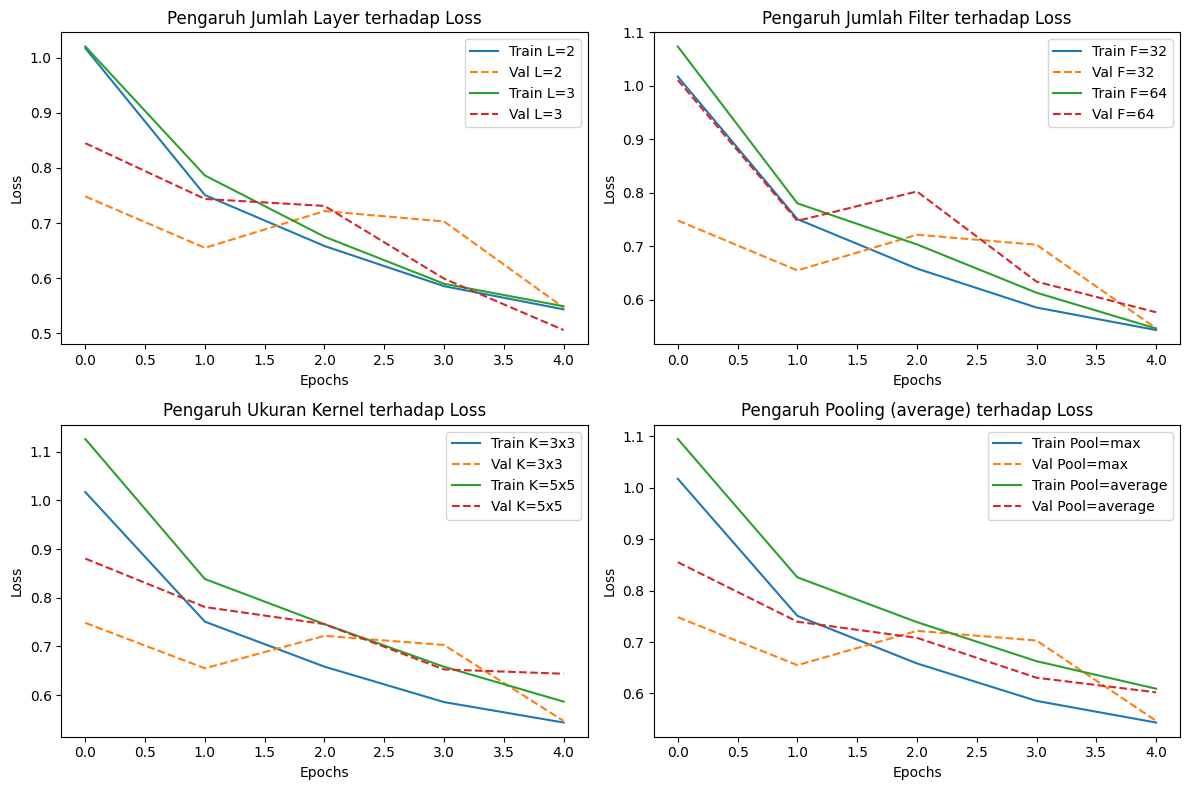

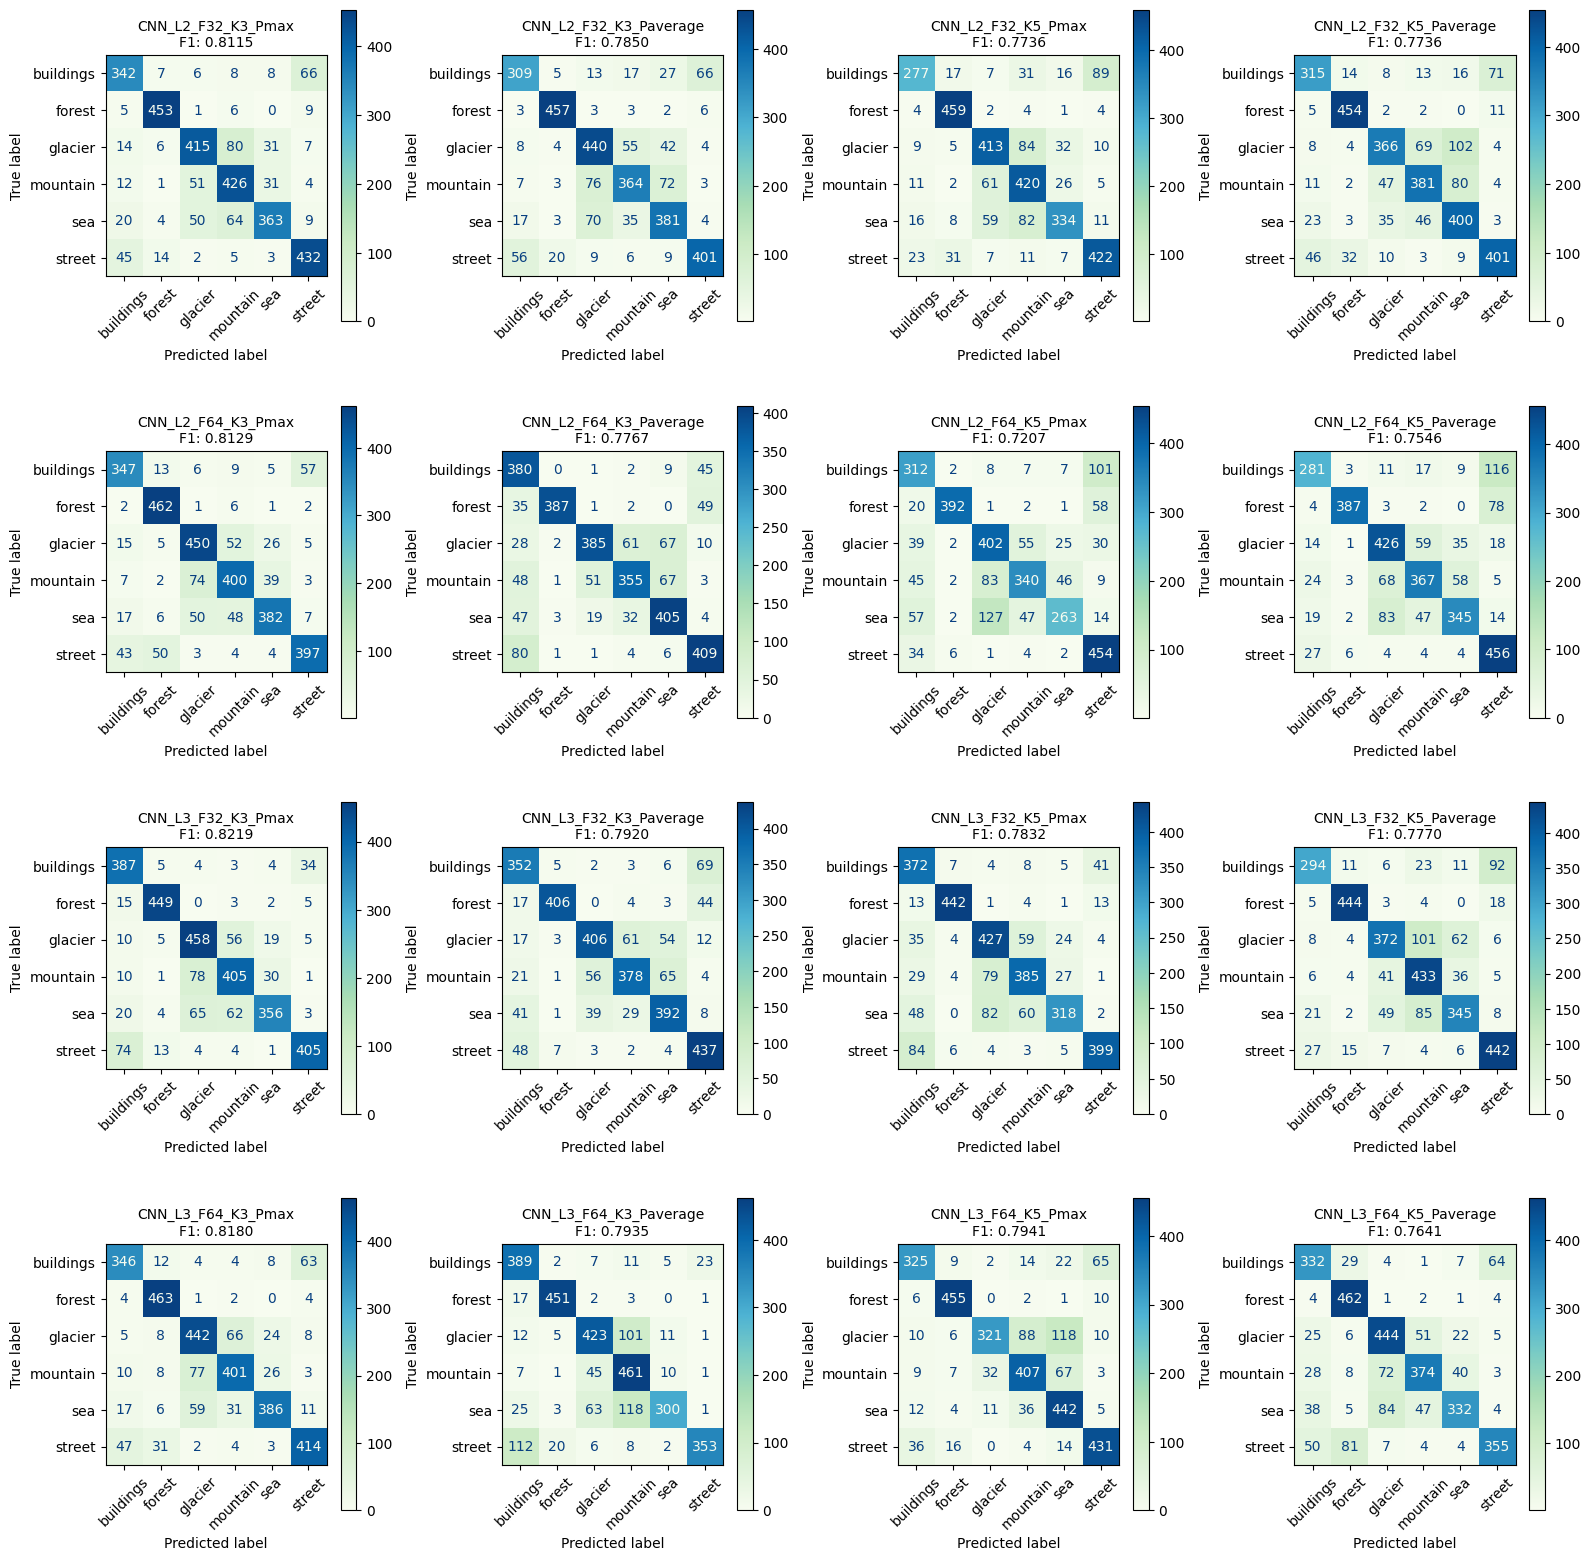

In [33]:
print("=== Average Macro F1: Layer Counts ===")
print(df_results.groupby('n_layers')['f1_score'].mean().to_string())

print("=== Average Macro F1: Filter Counts ===")
print(df_results.groupby('n_filters')['f1_score'].mean().to_string())

print("=== Average Macro F1: Kernel Size ===")
print(df_results.groupby('kernel_size')['f1_score'].mean().to_string())

print("=== Average Macro F1: Pooling ===")
print(df_results.groupby('pooling')['f1_score'].mean().to_string())

# loss curve
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Layer Counts
for n_l in n_conv_vars:
    sample = next(res for res in all_results if res['n_layers'] == n_l)
    axes[0, 0].plot(sample['history']['loss'], label=f"Train L={n_l}")
    axes[0, 0].plot(sample['history']['val_loss'], linestyle='--', label=f"Val L={n_l}")
axes[0, 0].set_title("Pengaruh Jumlah Layer terhadap Loss")
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Filter Count
for n_f in n_filt_vars:
    sample = next(res for res in all_results if res['n_filters'] == n_f)
    axes[0, 1].plot(sample['history']['loss'], label=f"Train F={n_f}")
    axes[0, 1].plot(sample['history']['val_loss'], linestyle='--', label=f"Val F={n_f}")
axes[0, 1].set_title("Pengaruh Jumlah Filter terhadap Loss")
axes[0, 1].set_xlabel("Epochs")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# Kernel Size
for k_s in [3, 5]:
    sample = next(res for res in all_results if res['kernel_size'] == k_s)
    axes[1, 0].plot(sample['history']['loss'], label=f"Train K={k_s}x{k_s}")
    axes[1, 0].plot(sample['history']['val_loss'], linestyle='--', label=f"Val K={k_s}x{k_s}")
axes[1, 0].set_title("Pengaruh Ukuran Kernel terhadap Loss")
axes[1, 0].set_xlabel("Epochs")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Pooling
for p_v in pool_vars:
    sample = next(res for res in all_results if res['pooling'] == p_v)
    axes[1, 1].plot(sample['history']['loss'], label=f"Train Pool={p_v}")
    axes[1, 1].plot(sample['history']['val_loss'], linestyle='--', label=f"Val Pool={p_v}")
    axes[1, 1].set_title(f"Pengaruh Pooling ({p_v}) terhadap Loss")
axes[1, 1].set_xlabel("Epochs")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# confusion matrices
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel() 

for idx, res in enumerate(all_results):
    cm_model = confusion_matrix(y_true, res['y_pred'])
    disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=class_names)
    
    disp_model.plot(ax=axes[idx], cmap='GnBu', xticks_rotation=45)
    axes[idx].set_title(f"{res['model_name']}\nF1: {res['f1_score']:.4f}", fontsize=10)

plt.tight_layout()
plt.show()

#### 6.2.1 Analisis
Berdasarkan data rata-rata Macro F1-score dan loss curve, peningkatan jumlah layer konvolusi menjadi 3 layer (0.7930) dan penggunaan max pooling (0.7920) memberikan performa superior dibandingkan opsi lainnya. Loss curve mengonfirmasi bahwa kombinasi ini mempercepat konvergensi menuju error yang rendah dan stabil. Sebaliknya, penggunaan filter yang lebih banyak (64 filter) dan ukuran kernel yang lebih lebar (5x5) justru menurunkan performa rata-rata (menjadi 0.7793 dan 0.7676). Grafik loss memperlihatkan adanya fluktuasi dan perlambatan penurunan val loss pada filter 64 dan kernel 5x5, yang mengindikasikan bahwa kapasitas model yang terlalu besar memicu kejenuhan variansi fitur pada resolusi gambar dataset ini.

Jika ditinjau dari sebaran 16 confusion matrix, model dengan performa tertinggi adalah CNN_L3_F32_K3_Pmax (F1: 0.8219) dan yang terendah adalah CNN_L2_F64_K5_Pmax (F1: 0.7207). Di seluruh variasi arsitektur, terdapat pola misklasifikasi yang konsisten akibat kemiripan visual yang tinggi, terutama pada pertukaran kelas antara glacier dengan mountain, serta kelas buildings dengan street. Arsitektur terbaik dengan kernel 3x3 dan kedalaman 3 layer adalah yang paling efektif untuk meminimalkan error pada kelas-kelas tersebut dibandingkan arsitektur lainnya.

### 6.3 Scratch Shared vs Non-Shared

=== ANALISIS EVALUASI MODEL STRATCH ===
Macro F1-Score Shared                 : 0.6478
Macro F1-Score Non-Shared             : 0.6478
Parameters for Shared                 : 1,347,398
Parameters for Non-Shared             : 86,168,518
Parameters Ratio (Non-Shared/Shared)  : 63.95x


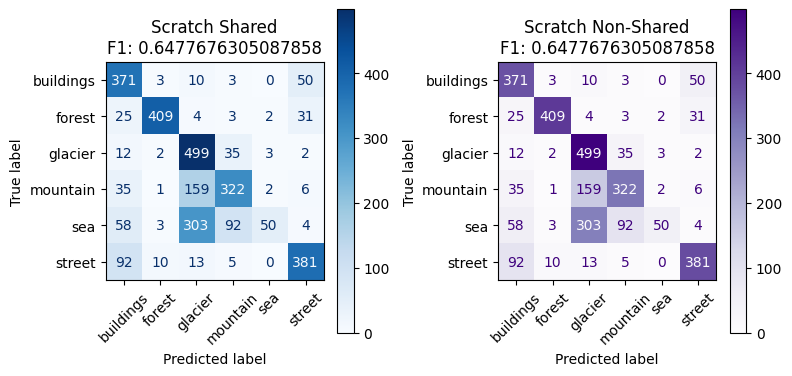

In [47]:
f1_shared = f1_score(y_true, y_pred_shared, average='macro')
f1_non_shared = f1_score(y_true, y_pred_non_shared, average='macro')


print("=== ANALISIS EVALUASI MODEL STRATCH ===")
print(f"Macro F1-Score Shared                 : {f1_shared:.4f}")
print(f"Macro F1-Score Non-Shared             : {f1_non_shared:.4f}")
print(f"Parameters for Shared                 : {params_shared:,}")
print(f"Parameters for Non-Shared             : {params_non_shared:,}")
print(f"Parameters Ratio (Non-Shared/Shared)  : {params_non_shared / params_shared:.2f}x")


# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

cm_shared = confusion_matrix(y_true, y_pred_shared)
disp_shared = ConfusionMatrixDisplay(confusion_matrix=cm_shared, display_labels=class_names)
disp_shared.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title(f"Scratch Shared\nF1: {f1_shared}")

cm_non_shared = confusion_matrix(y_true, y_pred_non_shared)
disp_non_shared = ConfusionMatrixDisplay(confusion_matrix=cm_non_shared, display_labels=class_names)
disp_non_shared.plot(ax=axes[1], cmap='Purples', xticks_rotation=45)
axes[1].set_title(f"Scratch Non-Shared\nF1: {f1_non_shared}")

plt.tight_layout()
plt.show()

#### 6.3.1 Analisis
Model Scratch Shared dan Scratch Non-Shared menghasilkan nilai Macro F1-score yang sama (0.6478) serta distribusi klasifikasi pada confusion matrix yang identik. Kesamaan ini menunjukkan keberhasilannya metode tiling parameter. Ketika bobot filter dari arsitektur shared dipetakan secara statis ke koordinat spasial lokal model non-shared, karakteristik ekstraksi fitur lokal yang telah dilatih tetap terjaga seutuhnya, sehingga tidak mengubah keputusan prediksi akhir model pada data uji. 

Perbedaan di antara keduanya terletak pada efisiensi parameter. Jumlah parameter pada model Non-Shared membengkak sebesar 63.95 kali lipat menjadi 86,168,518 parameter, dibandingkan model Shared yang hanya membutuhkan 1,347,398 parameter. Tentunya ini disebabkan oleh tiadanya weight sharing pada arsitektur non-shared, sehingga network mengalokasikan kernel dan bias yang berbeda untuk setiap titik koordinat spasial. Eksperimen ini menegaskan lagi bahwa penggunaan parameter sharing pada layer konvolusi penting untuk memangkas redundansi parameter dan menghemat memori komputasi tanpa menurunkan kualitas generalisasi model.

### 6.4 Kesimpulan Analisis
Implementasi forward propagation scratch mengalami penurunan performa sebesar 0.1741 yang bersumber dari implementasi forward propagation atau layer yang kurang bagus, terutama untuk pemisahan kelas seperti glacier dan buildings.

Konfigurasi Keras terbaik dicapai oleh model CNN_L3_F32_K3_Pmax (Layer = 3, Filter = 32, Kernel = 3x3, Pooling = max) dengan Macro F1 0.8219. Ini karena optimasi 3 layer dan max pooling mempercepat konvergensi, sedangkan penggunaan filter 64 dan kernel 5x5 justru menurunkan performa akibat kejenuhan fitur spasial.  

Pengujian shared vs non-shared menghasilkan nilai performa dan distribusi confusion matrix yang identik (0.6478), namun ketiadaan mekanisme weight sharing pada arsitektur non-shared memicu lonjakan parameter drastis hingga 63.95 kali lipat (86.168.518 parameter), menegaskan bahwa parameter sharing pada layer konvolusi standar sangat penting untuk efisiensi memori komputasi tanpa mengurangi kualitas model.